# Introduction

We live in a digital age flooded with information, where distinguishing between fact and fiction has become increasingly challenging. Among the rising concerns is misinformation, or "fake news," a phenomenon that undermines trust and credibility in our sources. To combat fake news, we can leverage the power of machine learning and robust tools. In this tutorial, you'll gain hands-on experience developing classifiers with Keras to identify and categorize news articles.

In deep learning, Keras serves as a high-level API that can run on top of various backend engines. In this tutorial, we explicitly set the backend using TensorFlow:

In [65]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

Now, let's load the packages required for the model-building process. I'll provide additional explanations along the way for some of the packages I’ve chosen.

In [66]:
import re
import keras
import string
import numpy as np
import pandas as pd
import tensorflow as tf
from keras import utils
from keras import layers
from keras import losses
from nltk import download
import plotly.express as px
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from sklearn.decomposition import PCA
from keras.layers import TextVectorization
from tensorflow.keras.optimizers import Adam

In the upcoming text processing steps, we'll need to remove stopwords. To prepare for this, we'll download the stopwords from `nltk.corpus` package as part of the setup process:

In [67]:
# Download stopwords
download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Acquire Training Data

Here is the training dataset we'll use for this practice. Let's load it into the notebook:

In [68]:
# Load dataset
train_url = "https://github.com/PhilChodrow/PIC16b/blob/master/datasets/fake_news_train.csv?raw=true"
df = pd.read_csv(train_url)

In [69]:
# Examine dataset
df.head()

,Unnamed: 0,title,text,fake
0,17366,Merkel: Strong result for Austria's FPO 'big c...,German Chancellor Angela Merkel said on Monday...,0
1,5634,Trump says Pence will lead voter fraud panel,"WEST PALM BEACH, Fla.President Donald Trump sa...",0
2,17487,JUST IN: SUSPECTED LEAKER and “Close Confidant...,"On December 5, 2017, Circa s Sara Carter warne...",1
3,12217,Thyssenkrupp has offered help to Argentina ove...,"Germany s Thyssenkrupp, has offered assistance...",0
4,5535,Trump say appeals court decision on travel ban...,President Donald Trump on Thursday called the ...,0


## Preprocess Training Data

### 1.1 Create 'make_dataset' Function

Passing a `tf.data.Dataset` into Keras is essential for efficient, flexible, and scalable input data handling when training deep learning models. Therefore, we write a function to preprocess the text input and transform the dataset into a `tf.data.Dataset`. To improve model training efficiency and ensure consistency in text formatting, we convert all characters in the text to lowercase. Additionally, we remove stopwords, which are commonly used words like "the", "and", and "but" that carry little semantic value and could introduce noise to the model. Lastly, we separate the title and text columns as inputs for the final tf.data.Dataset, and the fake column is designated as the output. Moreover, to enhance the efficiency of model training, we process the data in batches before returning it. Batching allows the model to train on chunks of data at a time instead of processing individual rows, which can significantly reduce computation time and improve overall performance. For this tutorial, the default batch size is set to 100, balancing training speed and accuracy. You can adjust the batch size based on the specific requirements and computational capacity of your environment.

In [70]:
def make_dataset(df, batch_size = 100):
    """
    Preprocess the 'text' and 'title' columns in the dataset
    by converting all text to lowercase and removing stopwords
    Args:
        df(DataFrame): A dataset with 'title', 'text', and 'fake' columns
        batch_size(int): The number of rows per batch in the Dataset (default 100)
    Returns:
        data(tf.data.Dataset): A dataset with inputs (title, text) and outputs (fake)
    """
    # Initialize stop words
    stop_words = set(stopwords.words('english'))

    def preprocess_text(text):
        """
        Preprocesses a text string by converting the text to lowercase and removing stopwords
        Args:
            text (str): The input text string
        Returns:
            text_processed(str): Text processed to lowercase with stopwords removed
        """
        # Convert text to lowercase
        text_processed = text.lower()
        # Remove stopwords
        text_processed = ' '.join(word for word in text_processed.split() if word not in stop_words)
        return text_processed

    # Apply pre_process_text on 'title' and 'text' columns
    df['title'] = df['title'].apply(preprocess_text)
    df['text'] = df['text'].apply(preprocess_text)

    # Extract input and output
    title = df['title'].values
    text = df['text'].values
    fake = df['fake'].values

    # Construct a tf.data.Dataset with 2 inputs and 1 output
    data = tf.data.Dataset.from_tensor_slices(((title, text), fake)).batch(batch_size)

    return data

We apply the function to the training dataset to preprocess the text and transform it into a `tf.data.Dataset`.

In [71]:
# Create the data by calling make_dataset
data = make_dataset(df)

### 1.2 Split Dataset

In this section, we will separate the data into training and validation sets for the later training process.

In [72]:
# Shuffle the dataset
data = data.shuffle(buffer_size = len(data), reshuffle_each_iteration=False)

The training dataset will consist of 80% of the data, while the validation dataset will make up the remaining 20%. Since we cannot directly apply train_test_split to a `tf.data.Dataset`, we will manually split the data to ensure the correct partitioning.

In [73]:
# Perform train-test split
train_size = int(0.8 * len(data))
val_size = int(0.2 * len(data))

train_data = data.take(train_size)
val_data = data.skip(train_size).take(val_size)

### 1.3 Determine Base Rate

Before building the model, we first determine the base rate, which represents the accuracy of a model that always predicts the most frequent label in the dataset. This "base model" serves as a reference point for evaluating how well our trained model performs. To do this, we write a function to count the number of occurrences of each label: 1 for fake news and 0 for true news. By calculating the proportion of fake vs. true news in the training dataset, we gain insight into the distribution of labels and set a baseline for model comparison.

In [74]:
# Define a function to count occurrences of fake news
def count_labels(data):
    """
    Count the number of fake/true news in given data
    Args:
        data(tf.data.Dataset): A dataset consisting of batches of features with labels
    Returns:
        fake_counter(int): number of fake news
        true_counter(int): number of true news
    """
    # Initialize counters for fake/true news
    fake_counter = 0
    true_counter = 1

    # Iterate through the data
    for _, labels in data:
        fake_counter += tf.reduce_sum(tf.cast(labels == 1, tf.int32)).numpy()
        true_counter += tf.reduce_sum(tf.cast(labels == 0, tf.int32)).numpy()

    return fake_counter, true_counter

In [75]:
# Count 1s and 0s in labels of train_data
fake, true = count_labels(train_data)

print(f"Count of fake news (1): {fake}")
print(f"Count of non-fake news (0): {true}")
print(f"Baseline of Model: {round(max(fake, true)/(true+fake) * 100, 2)}")

Count of fake news (1): 9396
Count of non-fake news (0): 8554
Baseline of Model: 52.35


In [76]:
# Prediction on val_data
fake_val, true_val = count_labels(val_data)
print(f"Baseline Model Accuracy on Validation Data: {round(fake_val/(fake_val+true_val) * 100, 2)}")

Baseline Model Accuracy on Validation Data: 52.08


In this case, the dataset contains a higher proportion of fake news, so the base model, which always outputs the label 1 (fake news), will achieve the highest possible accuracy by predicting the most frequent label. However, this approach does not provide meaningful insights, as the model is not learning to distinguish between fake and true news. Ultimately, the base model achieves an accuracy of around 53%. This base rate serves as a benchmark to evaluate the performance of more sophisticated models that aim to actually learn patterns from the data.

### 1.4 Text Vectorization

Text vectorization is a crucial step in natural language processing, as it transforms raw text into numerical representations that machine learning models can understand. We will define a standardization function and a text vectorization layer to convert text data into tokens, making it easier for our model to process. We need to clean and standardize the text before feeding it into our model. Below, we define a function that lowers the case of the input text and removes any punctuation:

In [77]:
size_vocabulary = 2000

In [78]:
# Define a standardization function
def standardization(input_data):
    lowercase = tf.strings.lower(input_data)
    no_punctuation = tf.strings.regex_replace(lowercase,
                                  '[%s]' % re.escape(string.punctuation),'')
    return no_punctuation

Now, we create a function that defines a TextVectorization layer. This layer will transform the raw text data into integer tokens. We also provide options to adjust the maximum vocabulary size and the output sequence length. This function also takes the previously defined standardization function as input for text preprocessing:

In [79]:
# Define a function to generate vectorization layer
def text_vectorization_layer(data,
                             column_index,
                             standardization_method = standardization,
                             max_token_size = 2000,
                             output_length=500):
    """
    Creates a TextVectorization layer for a column of data.

    Args:
        train_data(tf.data.Dataset): The dataset for text vectorization
        column_index (int): The index of the column in data
        standardization_method(function): Standardization function to apply to the text
        max_token_size(int): The maximum number of token
        output_length(int): The output sequence length
    Returns:
        vectorize_layer(TextVectorization): A fitted TextVectorization layer.
    """
    # Define vectorized layer construction
    vectorize_layer = TextVectorization(
        standardize = standardization_method,
        max_tokens = max_token_size,
        output_mode = 'int',
        output_sequence_length = output_length
    )

    # Adapt the layer on the column specified
    vectorize_layer.adapt(train_data.map(lambda x, y: x[column_index]))

    return vectorize_layer

We now apply the text_vectorization_layer function to both the title and text columns of our dataset. These columns are typically indexed as 0 and 1, respectively, and we will use the function to create the respective vectorization layers.

In [80]:
title_vectorize_layer = text_vectorization_layer(train_data, column_index=0)
text_vectorize_layer = text_vectorization_layer(train_data, column_index=1)



Now that we have preprocessed and vectorized our text data, we can proceed to the model-building phase. A critical question arises in the process of detecting fake news: Is it more effective to focus on only the title of the article, the full text of the article, or both?

Intuitively, we might expect that the full text of the article provides more context and therefore may be more effective than just the title. However, it's worth testing this hypothesis by building three separate models—one focusing on the title, one on the full text, and one on both the title and the text—and comparing their performance.

## Model 1 - Title Only

We start by defining input layers for the title and the full text. For now, we will focus on the title input.

In [81]:
# Initialize inputs
title_input = keras.Input(
    shape = (1,),
    name = "title",
    dtype = "string"
)
text_input = keras.Input(
    shape = (1,),
    name = "text",
    dtype = "string"
)

Next, we process the title using a TextVectorization layer, followed by an embedding layer, and other layers for regularization and feature extraction. <br>
- **TextVectorization Layer**: This layer tokenizes and normalizes the text. <br>
- **Embedding Layer**: This layer converts tokenized input into dense vectors of fixed size 3 that helps ti capture semantic relationships between words. <br>
- **Dropout Layers**: These layers randomly disable a fraction of neurons during training to prevent overfitting. <br>
- **GlobalAveragePooling1D**: This layer averages the sequence of word embeddings into a fixed-size vector, simplifying the representation of the title.

In [82]:
# layers for processing the title
title_features = title_vectorize_layer(title_input)
title_features = layers.Embedding(size_vocabulary, 3, name = "embedding_title")(title_features)
title_features = layers.Dropout(0.2)(title_features)
title_features = layers.GlobalAveragePooling1D()(title_features)
title_features = layers.Dropout(0.2)(title_features)
title_output = layers.Dense(1, activation='sigmoid')(title_features)

Now we can create the Keras model:

In [83]:
# Create model_1
model_1 = keras.Model(inputs = title_input,
                      outputs = title_output)

In [84]:
# Compile model_1
model_1.compile(optimizer = Adam(learning_rate=0.005),
                loss = 'binary_crossentropy',
                metrics = ['accuracy'])

We can use utils.plot_model to visualize the architecture of the model:

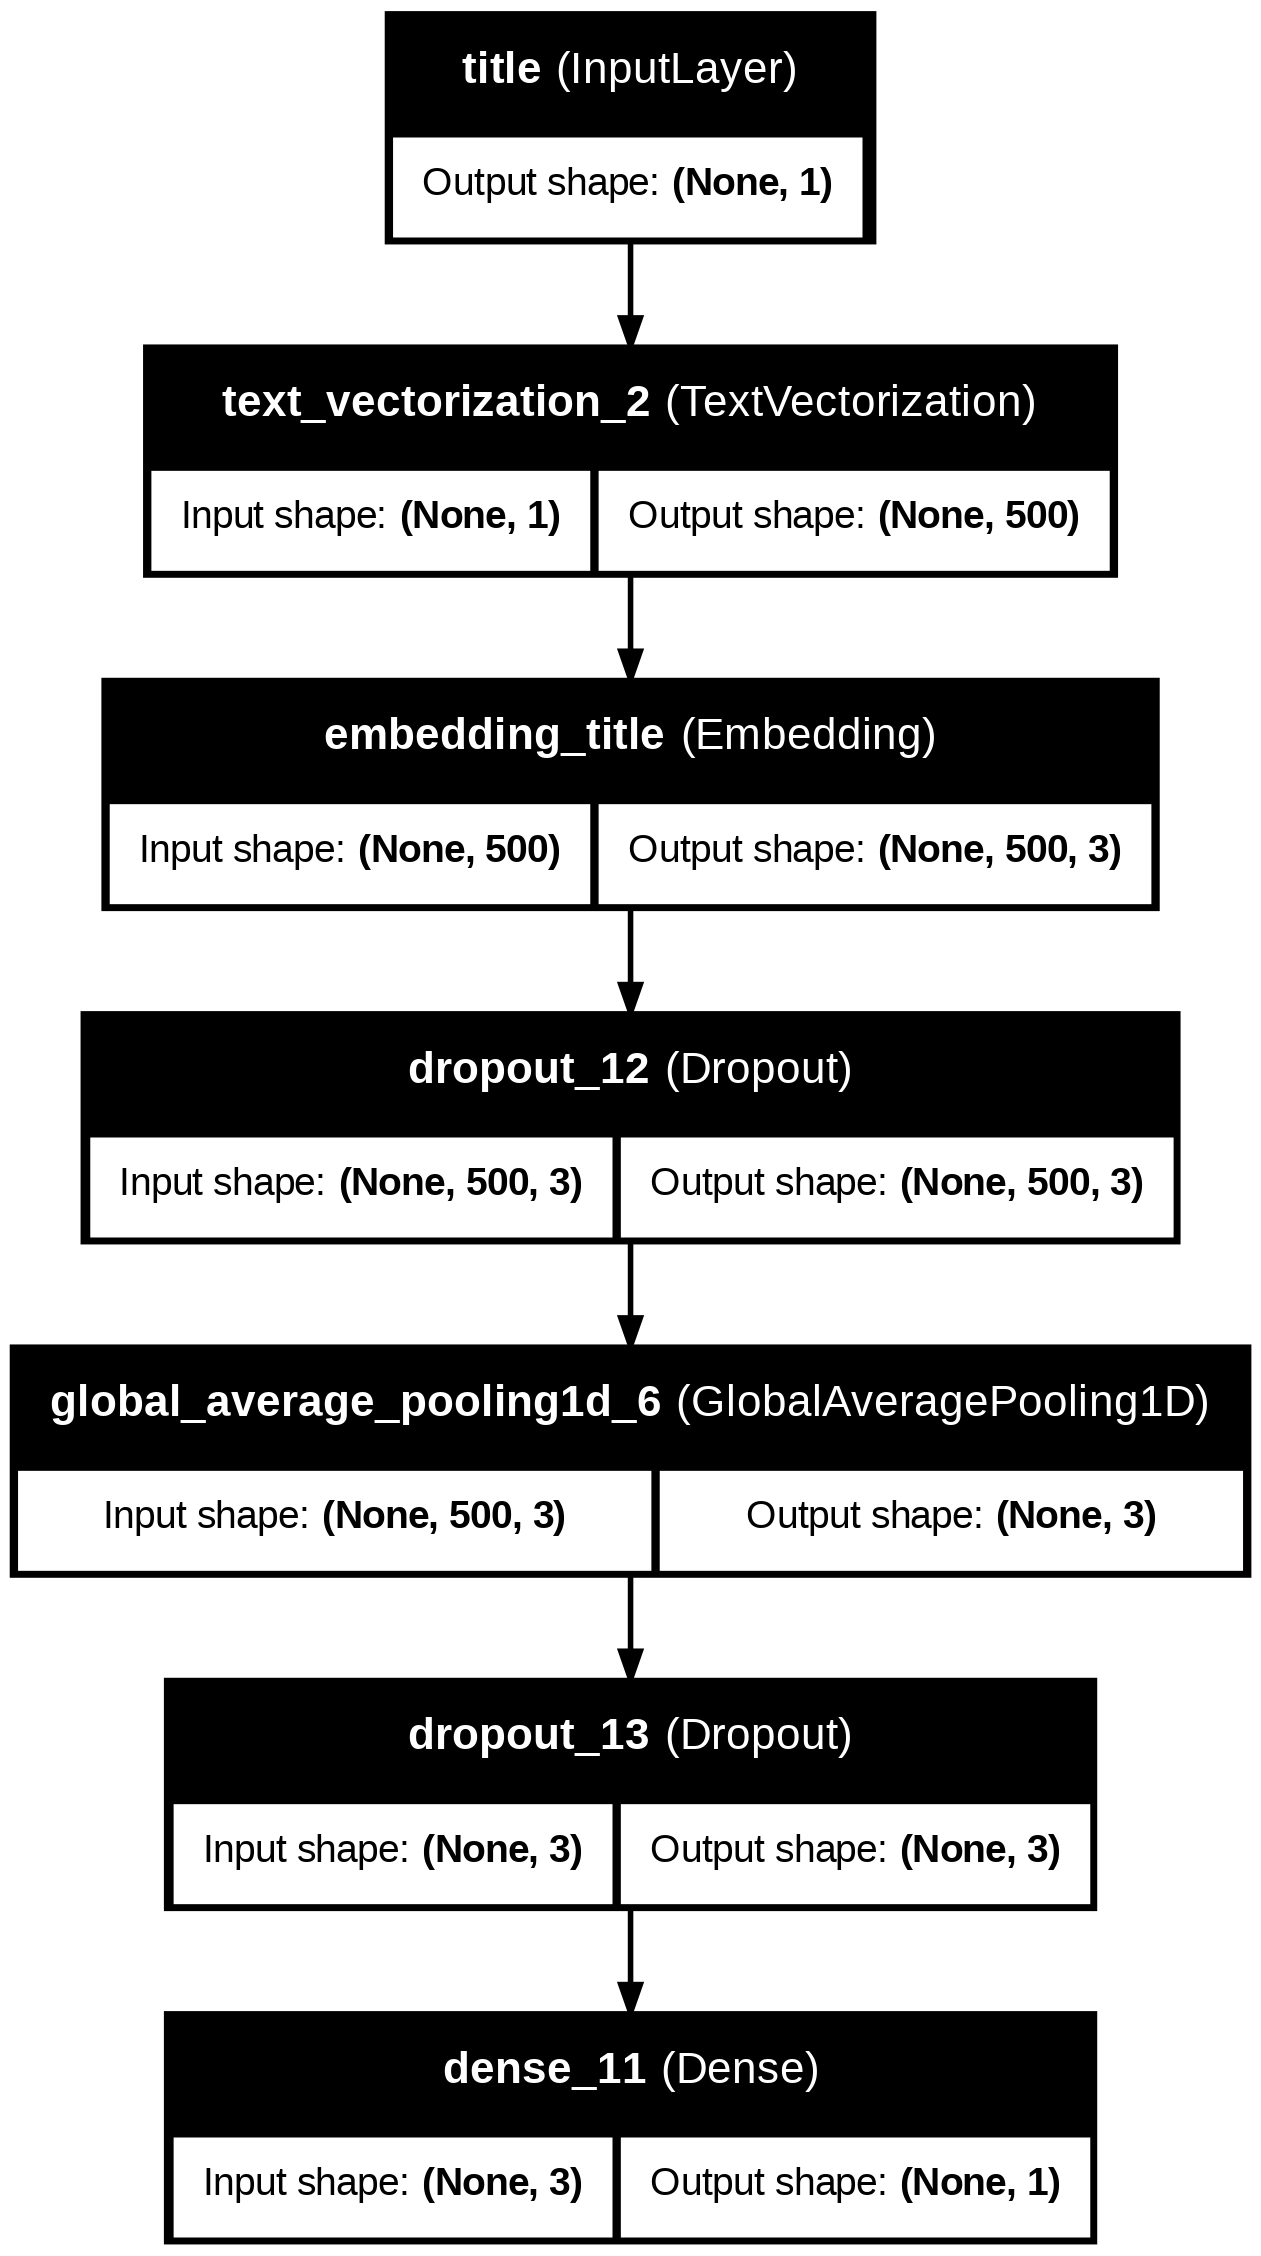

In [85]:
# Visualize model_1
utils.plot_model(model_1, "model_1.png",
                 show_shapes = True,
                 show_layer_names = True)

Before training the model, we need to preprocess the training and validation datasets to extract only the title input and the labels. We use the map function to format the data appropriately.

In [86]:
# Extract only the "title" input and labels
train_data_processed_1 = train_data.map(lambda x, y: ({"title": x[0]}, y))
val_data_processed_1 = val_data.map(lambda x, y: ({"title": x[0]}, y))

Finally, we train the model using the processed data. We will also set up early stopping to monitor the validation loss and stop training if the loss does not improve for 10 consecutive epochs.

In [87]:
callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

In [88]:
# Train the model
history_1 = model_1.fit(
    train_data_processed_1,
    validation_data=val_data_processed_1,
    epochs=50,
    callbacks=[callback],
    verbose=True
)

Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.5188 - loss: 0.6929 - val_accuracy: 0.5484 - val_loss: 0.6875
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5537 - loss: 0.6847 - val_accuracy: 0.5233 - val_loss: 0.6719
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5926 - loss: 0.6685 - val_accuracy: 0.7669 - val_loss: 0.6361
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.6549 - loss: 0.6321 - val_accuracy: 0.6111 - val_loss: 0.6234
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.7012 - loss: 0.5893 - val_accuracy: 0.7562 - val_loss: 0.5505
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.7532 - loss: 0.5432 - val_accuracy: 0.7940 - val_loss: 0.5017
Epoch 7/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7699 - loss: 0.5094 - val_accuracy: 0.8082 - val_loss: 0.4693
Epoch 8/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7788 - loss: 0.4830 - val_accu

In [89]:
def plot_accuracy(history):
    plt.plot(history.history["accuracy"], label = "training")
    plt.plot(history.history["val_accuracy"], label = "validation")
    plt.gca().set(xlabel = "epoch", ylabel = "accuracy")
    plt.legend()
    plt.show()

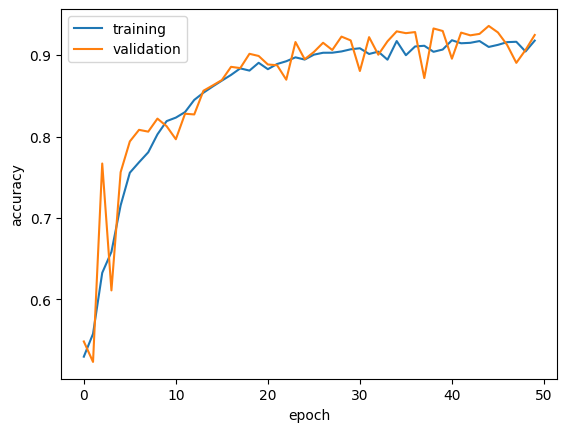

In [90]:
plot_accuracy(history_1)

The first model generally achieves a satisfactory accuracy on both the training and validation datasets after 50 epochs of training. The training history displayed reflects a positive result, with the validation accuracy consistently staying above the training accuracy, indicating no sign of overfitting.

Initially, the accuracy plot progress slow and ended with a sharp incline which suggested that the learning rate might be too low for model convergence. To address this, I manually adjusted the learning rate of the optimizer to accelerate the the model’s learning process while ensuring it remained stable. This adjustment helped improve the model’s ability to classify fake news more efficiently, promoting faster learning and a smoother trajectory in both training and validation accuracy.

The model stabilized around **90.5 - 92.5** for `model_1`.

## Model 2 Text Only

The second model uses only the text of the news article. The setup is very similar to the first model, with a few differences.

In [91]:
# layers for processing the text
text_features = title_vectorize_layer(text_input)
text_features = layers.Embedding(size_vocabulary, 3, name = "embedding_text")(text_features)
text_features = layers.Dropout(0.2)(text_features)
text_features = layers.Dense(32, activation='relu')(text_features)
text_features = layers.GlobalAveragePooling1D()(text_features)
text_features = layers.Dropout(0.3)(text_features)
text_output = layers.Dense(1, activation='sigmoid')(text_features)

In [92]:
# Create model_2
model_2 = keras.Model(inputs = text_input,
                      outputs = text_output)

In [93]:
# Compile model_2
model_2.compile(optimizer = Adam(learning_rate=0.001),
                loss = 'binary_crossentropy',
                metrics = ['accuracy'])

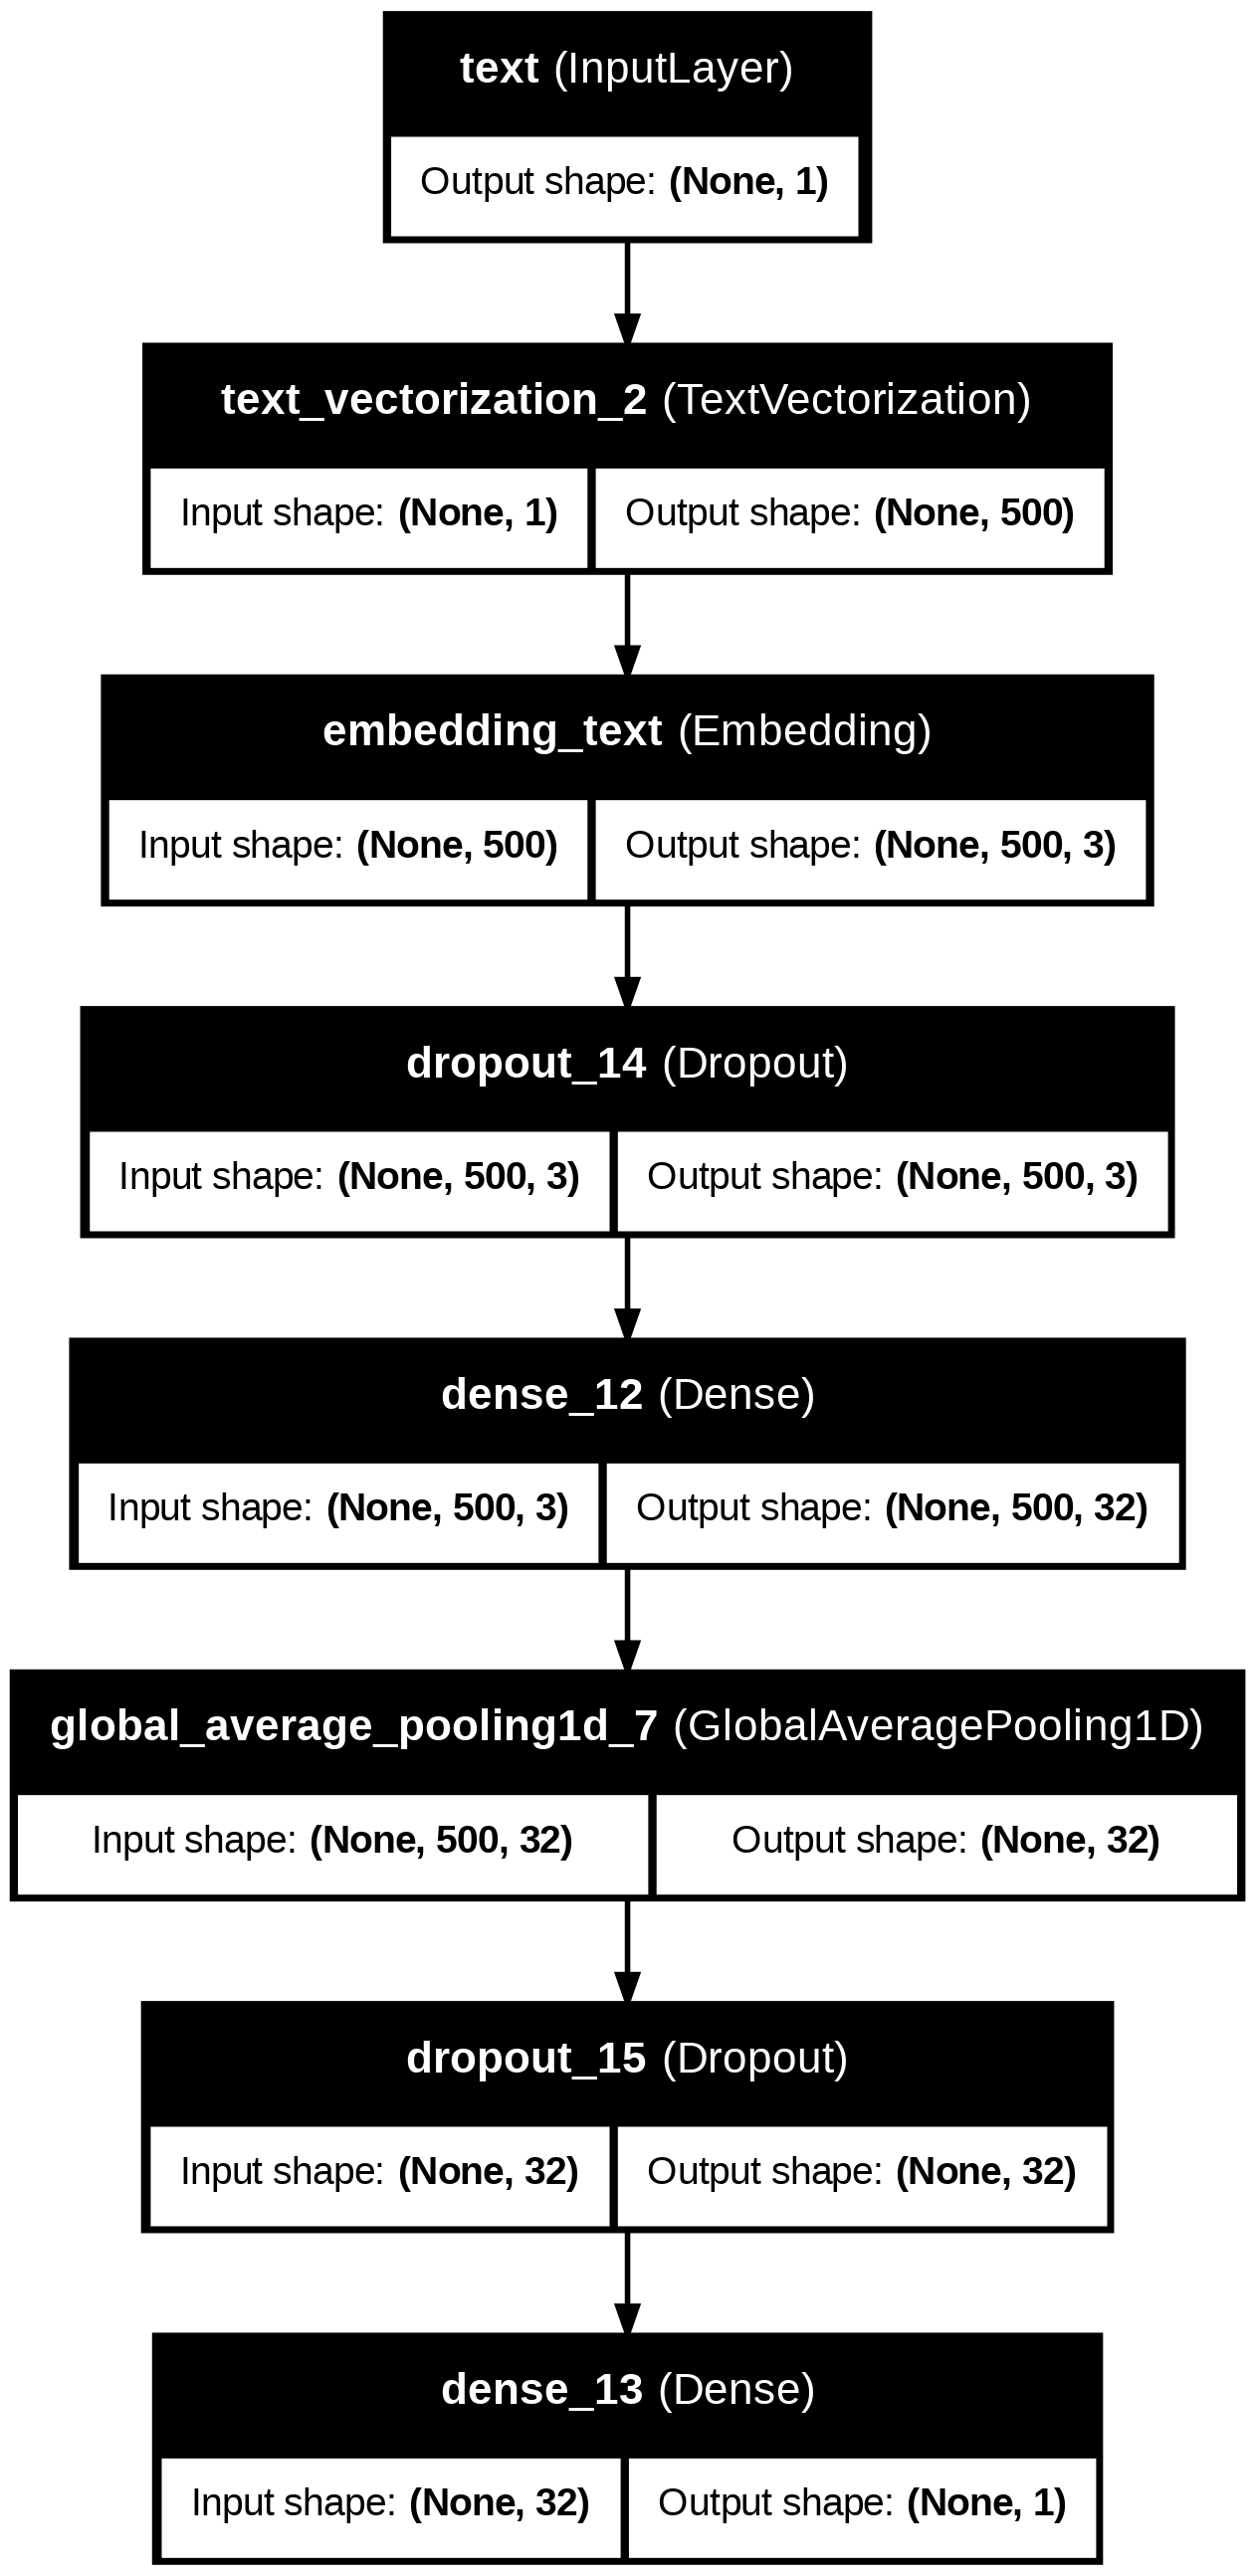

In [94]:
# Visualize model_2
utils.plot_model(model_2, "model_2.png",
                 show_shapes = True,
                 show_layer_names = True)

In [95]:
# Extract only the "text" input and labels
train_data_processed_2 = train_data.map(lambda x, y: ({"text": x[1]}, y))
val_data_processed_2 = val_data.map(lambda x, y: ({"text": x[1]}, y))

In [96]:
# Train the model
history_2 = model_2.fit(
    train_data_processed_2,
    validation_data=val_data_processed_2,
    epochs=50,
    callbacks=[callback],
    verbose=True
)

Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.5248 - loss: 0.6900 - val_accuracy: 0.6647 - val_loss: 0.6684
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.6965 - loss: 0.6440 - val_accuracy: 0.8227 - val_loss: 0.5184
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.8353 - loss: 0.4871 - val_accuracy: 0.9142 - val_loss: 0.3635
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.8810 - loss: 0.3730 - val_accuracy: 0.9360 - val_loss: 0.2847
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.8960 - loss: 0.3125 - val_accuracy: 0.9442 - val_loss: 0.2413
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.9100 - loss: 0.2779 - val_accuracy: 0.9491 - val_loss: 0.2159
Epoch 7/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.9213 - loss: 0.2481 - val_accuracy: 0.9518 - val_loss: 0.1978
Epoch 8/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.9248 - loss: 0.2312 - val_a

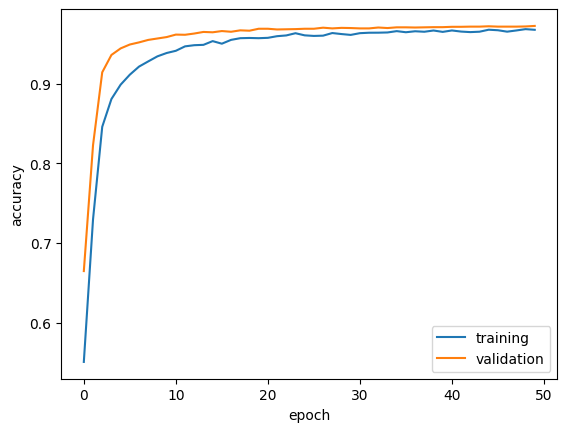

In [97]:
plot_accuracy(history_2)

By directly inheriting the exact structure from the first model and adjusting for the text input, the model achieves superior performance, reaching a validation accuracy above 96%. This demonstrates that the full text of the news article provides more information for the model to work with, allowing it to make more accurate predictions compared to just using the title.

Due to the more complex nature of the full text compared to just the title, I added an additional Dense layer to the model. This extra layer allows the model to better capture the intricate relationships and patterns present in the text, leading to improved performance. The added layer helps the model learn more abstract features and better generalize to unseen data, making it more robust.

The model stabilized around **97.1 - 97.3** for `model_2`.

## Model 3 Combine Title & Text

In the final model, we take a combined approach by concatenating the layers from the previous two models to see if this integration can lead to better results. Instead of redefining the layers used in the first two models, we use the `layers.concatenate` function to combine their respective outputs.

In [ ]:
# Concatenate the output of the title pipeline with text pipeline
main = layers.concatenate([title_output, text_output], axis = 1)

After concatenating the layers from the title and text models, we add additional layers to refine the combined features and ensure the output is suitable for binary classification.

In [ ]:
# Add more layer to the model
output = layers.Dense(1, activation='sigmoid')(main)

In [ ]:
# Create model_3
model_3 = keras.Model(
    inputs = [title_input, text_input],
    outputs = output
)

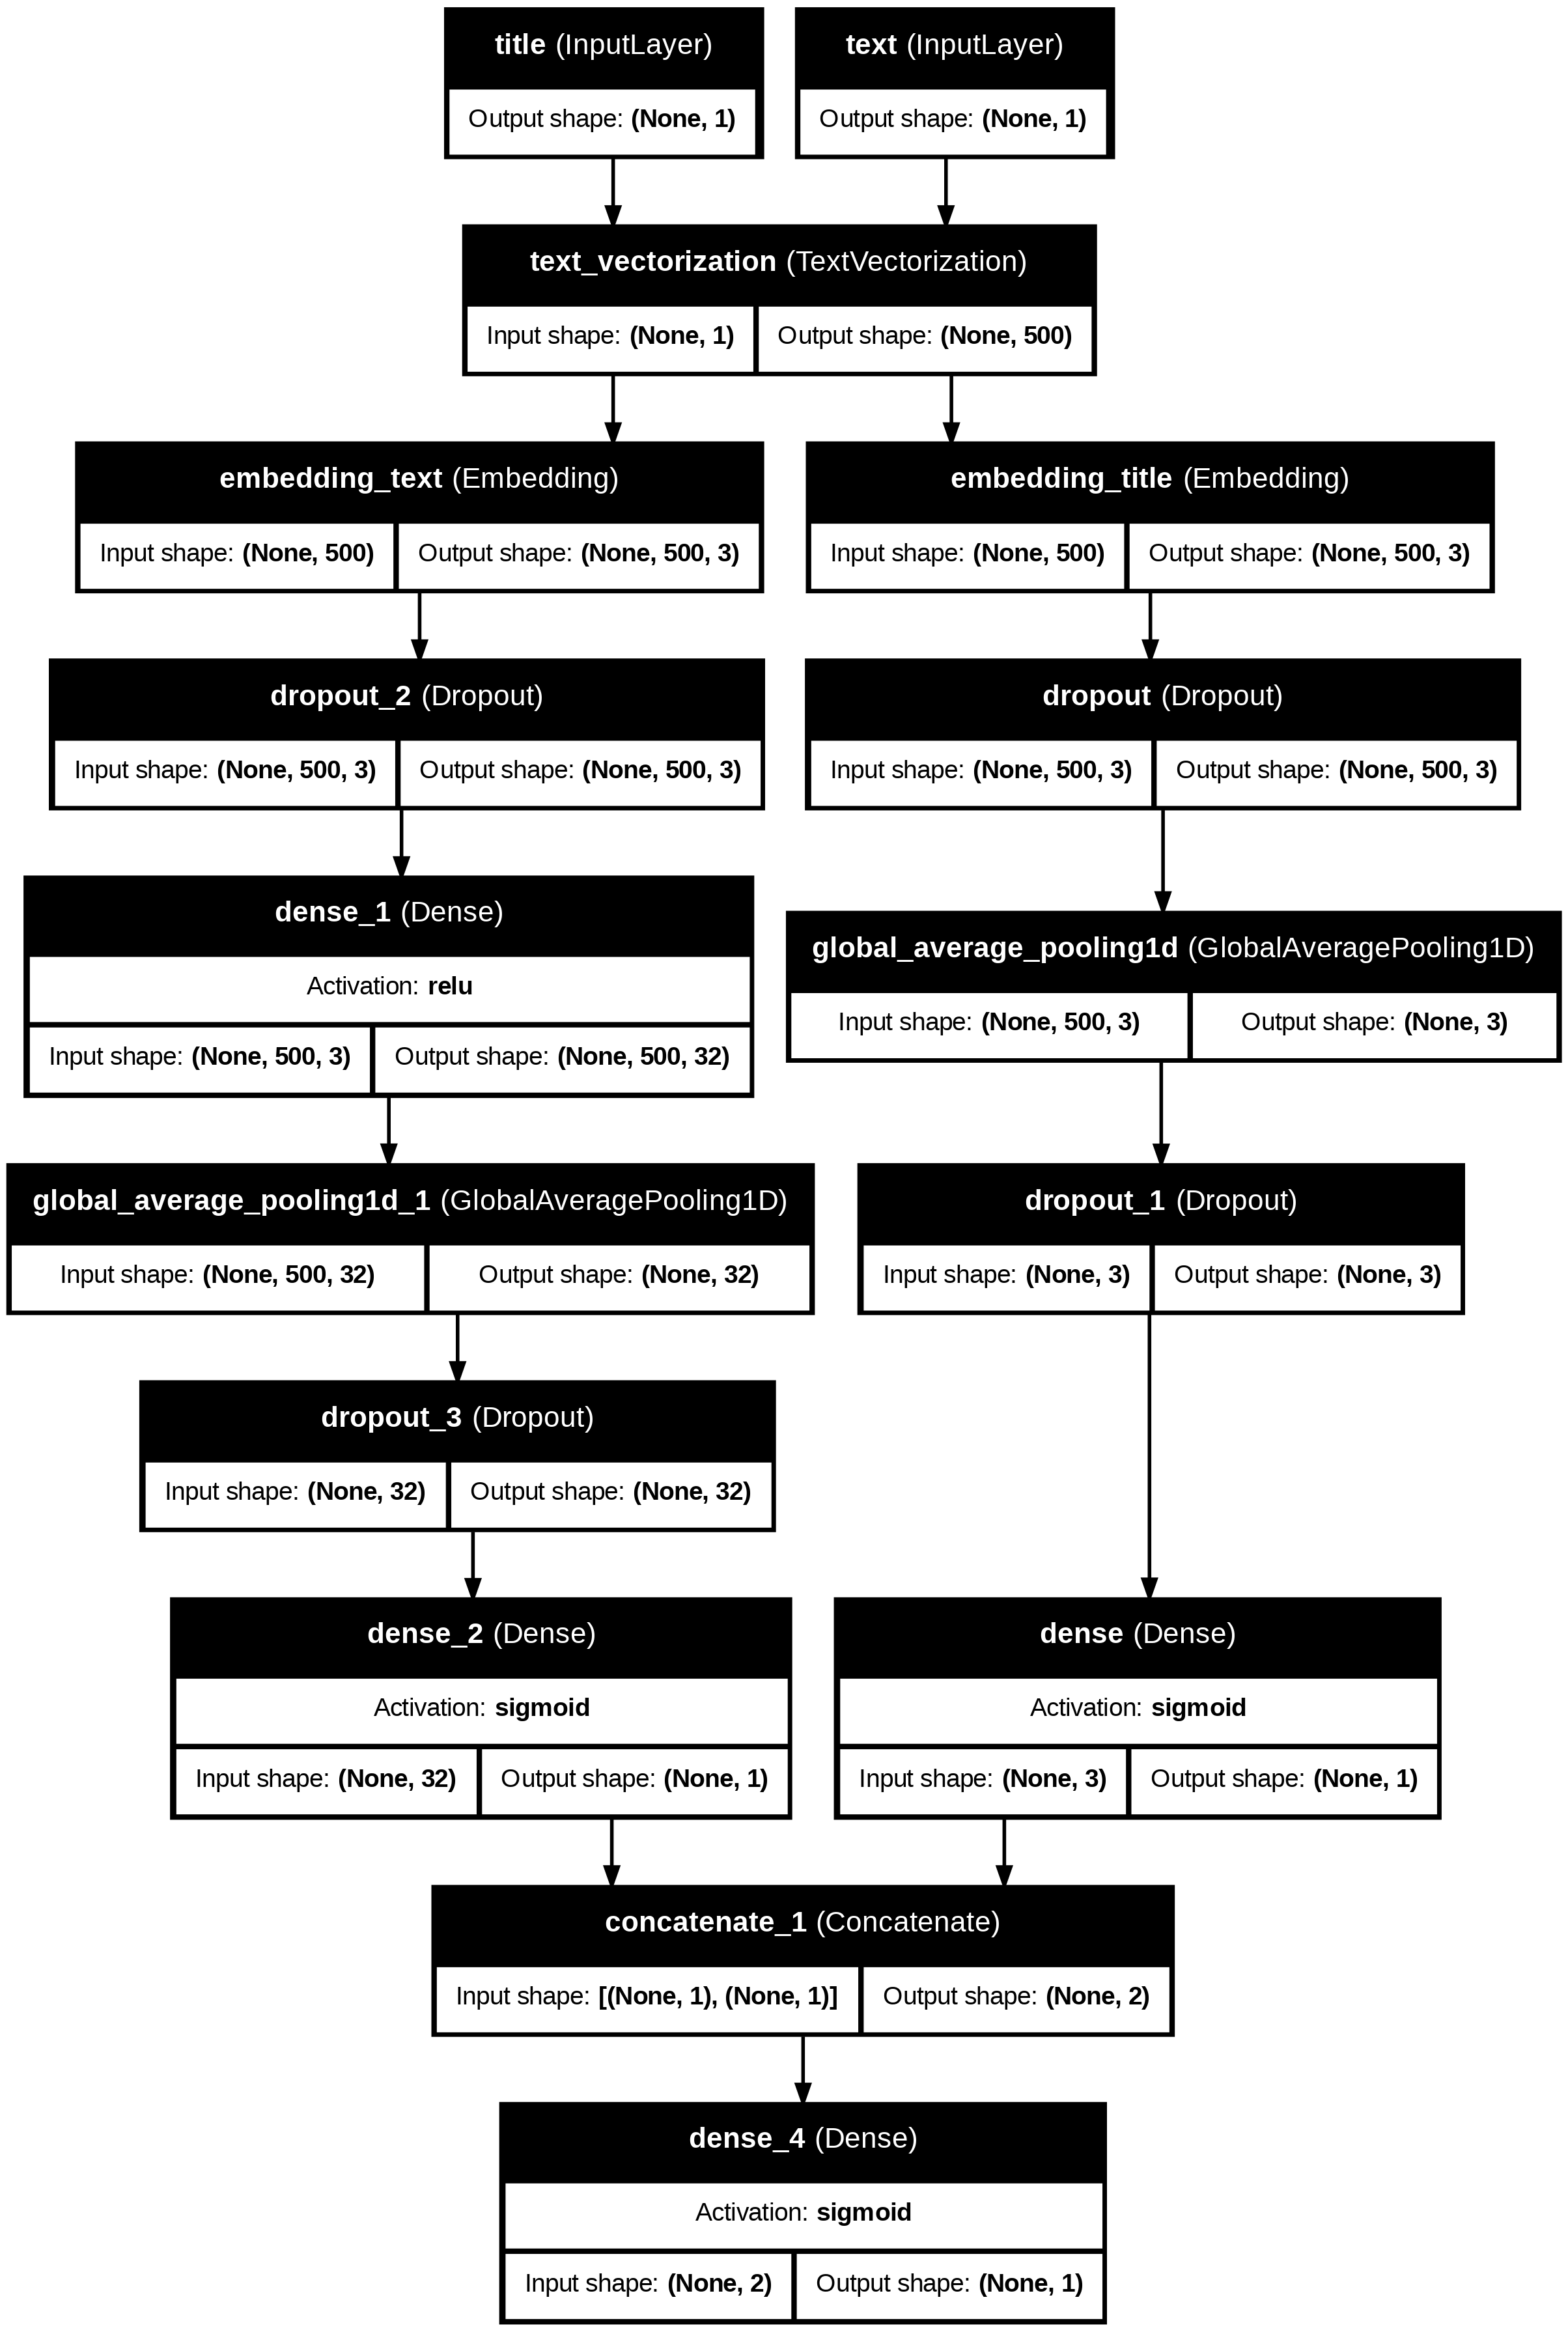

In [ ]:
# Visualize model_3
utils.plot_model(model_3, "model_3.png", show_shapes=True,
                show_layer_names=True,
                show_layer_activations=True)

In [ ]:
# Compile model_3
model_3.compile(optimizer = 'adam',
                loss = 'binary_crossentropy',
                metrics = ['accuracy'])

In [ ]:
# Train the model
history_3 = model_3.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[callback],
    verbose=True
)

Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.4077 - loss: 0.7817 - val_accuracy: 0.5133 - val_loss: 0.6989
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.5197 - loss: 0.6957 - val_accuracy: 0.5133 - val_loss: 0.6942
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.5171 - loss: 0.6939 - val_accuracy: 0.5133 - val_loss: 0.6935
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.5182 - loss: 0.6932 - val_accuracy: 0.5136 - val_loss: 0.6933
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.7617 - loss: 0.6476 - val_accuracy: 0.9664 - val_loss: 0.5655
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.9526 - loss: 0.5551 - val_accuracy: 0.9691 - val_loss: 0.5184
Epoch 7/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.9621 - loss: 0.5111 - val_accuracy: 0.9711 - val_loss: 0.4808
Epoch 8/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.9621 - loss: 0.4765 - val_

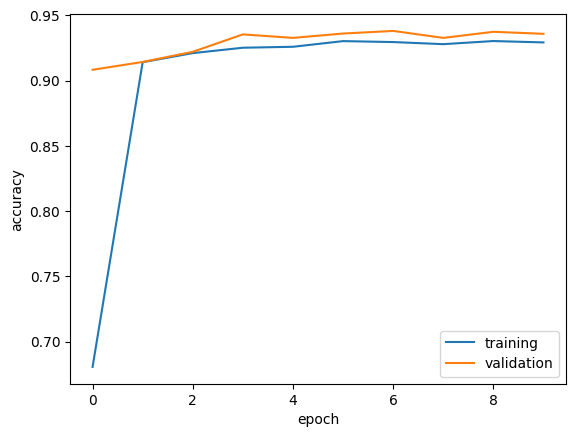

In [ ]:
plot_accuracy(history_3)

Model 3, which incorporates both the title and text of the news, achieves similar validation accuracy to Model 2. This indicates that including both inputs does not drastically outperform using only the text but still maintains competitive performance. The training process for Model 3 demonstrates rapid growth in performance, often reaching convergence and being halted by early stopping after just 10 to 15 epochs. There's no sign of overfitting in this model as well.

After training and evaluating all three models, we return to the initial regarding the most effective input for detecting fake news? Based on the results, the most effective solution in our case is to focus **only on the full text of the article**, as demonstrated by the better performance of **Model 2**.

The model stabilized around **90** to **97** for `model_2`.

## Model Evaluation

With `model_2` identified as the best-performing solution, it's time to evaluate its performance on the test dataset.

In [ ]:
# Load test dataset
test_url = "https://github.com/PhilChodrow/PIC16b/blob/master/datasets/fake_news_test.csv?raw=true"
test_df = pd.read_csv(test_url)

After loading the test set, we need to prepare the data using the make_dataset function implemented earlier. To ensure consistency, we pass only the text input to the model during evaluation.

In [ ]:
# Prepare the dataset for model
test_data = make_dataset(test_df)
test_data_processed = test_data.map(lambda x, y: ({"text": x[1]}, y))

In [ ]:
model_2.evaluate(test_data_processed)

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9701 - loss: 0.1190


[0.11956581473350525, 0.9708227515220642]

`model_2` achieves a final test accuracy of 97%, a highly satisfactory result that confirms the model's robustness and reliability in detecting fake news.

##  Embedding Visualization

Visualizing word embeddings helps us understand how words are represented in the feature space after being processed by the model. The embedding layer of `model_2` maps each word to a 3-dimensional vector. We retrieve these learned representations:

In [98]:
# Obtain weights from the embedding layer
weights = model_2.get_layer('embedding_text').get_weights()[0]
# Obtain vocabulary
vocab = text_vectorize_layer.get_vocabulary()

For visualization, we use PCA to reduce the 3-dimensional space of word embedding to two components.

In [99]:
# Initialize the PCA
pca = PCA(n_components=2)
# Apply PCA transformation to the 'weights' to reduce it to 2 components
weights = pca.fit_transform(weights)

Then we construct a DataFrame and plot the scatter plot based on the coordinates of the components.

In [100]:
# Create a DataFrame to store the word embeddings
embedding_df = pd.DataFrame({ 'word' : vocab, 'x0': weights[:,0], 'x1': weights[:,1]})

In [101]:
fig = px.scatter(embedding_df,
                 x = "x0",
                 y = "x1",
                 size = list(np.ones(len(embedding_df))),
                 size_max = 5,
                 hover_name = "word")

fig.show()

![Embedding Visualization](embedding.png)

In the word embedding visualization, we can observe several interesting semantic similarities based on the relative positioning of words in the 2D space. For instance, the words "global" and "homeland" are closely located, reflecting their related meanings in the context of national or international issues. Similarly, "jail" and "threat" are positioned near each other, indicating their connection in the context of crime and punishment. The words "gives", "sent", and "share" cluster together, highlighting their association with actions of conveying the transfer of something. Additionally, "innocent" and "victim" are grouped closely, capturing their shared context in discussions about justice and wrongdoing. These groupings in the embedding space reveal how the model captures semantic relationships and contextual similarities between words.

# Conlcusion

In this tutorial, we explored the process of building and evaluating a fake news detection model using Keras. We began by preparing the dataset, implementing text preprocessing, and applying vectorization techniques. After developing separate models focusing on the title, text, and a combination of both, we identified that the full text of the article provided the best results in terms of validation accuracy. We also examined the performance of the model on the test set, achieving an impressive accuracy of 97%. Lastly, we visualized the word embeddings from the trained model to understand the semantic relationships between words. By the end of this tutorial, you should have a solid understanding of how to approach text classification problems. Good luck with your own text classification exploration.